# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 1: *Fire Damage Data Processing*
##### Version Number: 2.0
---
### Contents  
> 1. *Cleaning and Filtering* 
> 2. *Calculating Damages*
> 3. *Visualize Damages*
> 4. *Export File*
---
### Notes

**Clean and process the [CAL FIRE Incident Data](https://www.fire.ca.gov/incidents)** dataset obtained from the California Open Data Portal. 
This code trims and cleans the data seperately from the other processing modules for easy adjustments to value calculations.

---
### Inputs

- `Damage_data_master.csv` - Contains Fire Location and Damage info

---
### Outputs  

- `fire_damages.csv` Cleaned fire damage dataset with dollar values associated with each fire event.

---
### User Created Dependencies  

After adjusting the system path to allow for imports from the parent directory, two custom utility functions are loaded:

- `basic_explore(df)`: Quickly summarizes a dataset (shape, nulls, datatypes, preview).
- `post_merge_check(df)`: Checks key indicators after merging datasets (row count, duplicates, key integrity).

These will be used for quick validation and sanity checks throughout the workflow.

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# utility function that prints details of a datset
from src.data_utils import basic_explore

# utility function printing relevant details to check the health after a dataset merge
from src.data_utils import post_merge_check

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde


---

### Third Party Dependencies

In [2]:
# core data handling
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from scipy.stats.mstats import winsorize

---

## 1. Cleaning and Filtering

### 1.1 Load File
`Damage_data_master` - Wildfire Incident Data on Structural Damage

Data obtained from CALFIRE website. Includes data on the degree of damages for every location since 1950. 

- Fire name and date started
- Damage levels (structures destroyed/damaged)
- County

In [3]:
raw_damages = pd.read_csv("../data/raw/Damage_data_master.csv",low_memory = False)
basic_explore(raw_damages)

Rows:  130722  Columns:  46
Duplicates  0
Total NA values:  1381634  of  6013212 datapoints


### 1.2 Preprocess Fire Damage Records

- Filtered down to essential columns: fire name, type, category, damage, date, and county.
- Renamed columns for consistency.
- Retained only fire-related records (excluding other hazard types).
- Converted the start date to `datetime.date`.
- Filtered records to match the analysis period starting from `2018-01-01`.

In [4]:
# filter to columns to keep
old_col_names = ['* Damage','County','Incident Start Date',
                 'Hazard Type', 'Structure Category','* Structure Type','* Incident Name',
                'Latitude','Longitude']
damages = raw_damages[old_col_names]

# rename for convenience
damages.columns = ['Damage','County', 'Start','Hazard','Category',
                  'Type','Fire Name','Lat','Lon']

# Filter for only fires, drop Hazard category, it is no longer needed
damages = damages[damages['Hazard'] == 'Fire']
damages = damages.drop(columns = ['Hazard'])

# filter the dataset to current operating time range
damages['Start'] = pd.to_datetime(damages['Start'], format='mixed').dt.date

In [5]:
basic_explore(damages)

Rows:  130720  Columns:  8
Duplicates  108
Total NA values:  30  of  1045760 datapoints


In [6]:
damages.isna().sum()

Damage        0
County       30
Start         0
Category      0
Type          0
Fire Name     0
Lat           0
Lon           0
dtype: int64

In [7]:
damages.info()

<class 'pandas.core.frame.DataFrame'>
Index: 130720 entries, 0 to 130721
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Damage     130720 non-null  object 
 1   County     130690 non-null  object 
 2   Start      130720 non-null  object 
 3   Category   130720 non-null  object 
 4   Type       130720 non-null  object 
 5   Fire Name  130720 non-null  object 
 6   Lat        130720 non-null  float64
 7   Lon        130720 non-null  float64
dtypes: float64(2), object(6)
memory usage: 9.0+ MB


**Note:**  
Approximately 30 records were missing county names in the original data. However, ZIP code and address information allowed inference of the correct county.  
Due to the small number, these corrections were applied manually by index.  
- Rows `78763–78773`: Riverside County  
- Rows `78435–78451`: Yuba County  
- Rows `88665` and `88681`: Tulare County  

These updates ensure completeness for spatial grouping and aggregation in downstream analysis.


In [9]:
riverside_ids = range(78763,78774)
yuba_ids = range(78435,78452)
damages.loc[riverside_ids,'County'] = 'Riverside'
damages.loc[yuba_ids,'County'] = 'Yuba'
damages.loc[88665,'County'] = 'Tulare'
damages.loc[88681,'County'] = 'Tulare'

In [10]:
display(damages.loc[list(riverside_ids) + list(yuba_ids) + [88665, 88681]])

,Damage,County,Start,Category,Type,Fire Name,Lat,Lon
78763,No Damage,Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.492899,-116.652934
78764,No Damage,Riverside,2021-08-24,Single Residence,Single Family Residence Multi Story,Rock,33.492826,-116.652699
78765,Destroyed (>50%),Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.491540,-116.659414
78766,Destroyed (>50%),Riverside,2021-08-24,Single Residence,Single Family Residence Multi Story,Rock,33.491304,-116.659441
78767,Destroyed (>50%),Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.484277,-116.657230
78768,Destroyed (>50%),Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.484294,-116.657084
78769,Destroyed (>50%),Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.485183,-116.659354
78770,Major (26-50%),Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.485174,-116.659206
78771,Destroyed (>50%),Riverside,2021-08-24,Single Residence,Mobile Home Single Wide,Rock,33.487423,-116.659194
78772,No Damage,Riverside,2021-08-24,Single Residence,Single Family Residence Single Story,Rock,33.482971,-116.664420


In [11]:
damages.head(2)

,Damage,County,Start,Category,Type,Fire Name,Lat,Lon
0,No Damage,Solano,2020-06-06,Single Residence,Single Family Residence Multi Story,Quail,38.474960,-122.044465
1,Affected (1-9%),Solano,2020-06-06,Single Residence,Single Family Residence Single Story,Quail,38.477442,-122.043252


---

## 2. Calculating Damages

### 2.1 Estimate Dollar Value of Structure Damage

To approximate the economic cost of fire damage, a base dollar value was assigned to each general structure type:

In [13]:
base_value_map = {
    'Single Residence': 800000,
    'Multiple Residence': 1000000,
    'Mixed Commercial/Residential': 1500000,
    'Nonresidential Commercial': 2000000,
    'Other Minor Structure': 10000,
    'Infrastructure': 1000000,
    'Agriculture': 10000,
}

### 2.2 Value Modifiers for Building Descriptors

The estimated dollar value for each damaged structure is adjusted based on detailed descriptors (e.g., building size, usage type). These modifiers scale the base value assigned to the general structure type.

> **Note:** These modifiers are heuristically defined to reflect relative structural value and are not based on official replacement costs.

In [14]:
type_modifier_map = {
    'Single Family Residence Multi Story': 1.0,
    'Single Family Residence Single Story': 0.95,
    'Utility Misc Structure': 0.1,
    'Mobile Home Double Wide': 0.5,
    'Motor Home': 0.3,
    'Multi Family Residence Multi Story': 1.2,
    'Commercial Building Single Story': 1.0,
    'Mobile Home Single Wide': 0.4,
    'Mixed Commercial/Residential': 1.5,
    'Mobile Home Triple Wide': 0.6,
    'Infrastructure': 0.8,
    'School': 1.3,
    'Multi Family Residence Single Story': 1.1,
    'Commercial Building Multi Story': 1.4,
    'Church': 1.0,
    'Hospital': 1.6,
    'Agriculture': 0.2,
    'Single Famliy Residence Single Story': 0.95,
    'Utility or Miscellaneous Structure > 120 sqft':0.1
}


### 2.3 Lookup Table: Estimated Damage Values by Structure Type and Descriptor

The estimated monetary damage per structure is computed by multiplying:
- A base value associated with the general **structure category** (Single Residence)
- A modifier associated with the **building descriptor** (Single Story, Mobile Home)

This matrix provides a quick reference for assigning dollar estimates to individual records based on their structure type and category.

> **Formula:**  
> `Estimated Value = Base Value × Type Modifier`


In [15]:
# Create a DataFrame from the Cartesian product of categories and types
value_matrix = pd.DataFrame(
    [(cat, typ, base_value_map[cat] * type_modifier_map[typ]) for cat in base_value_map for typ in type_modifier_map],
    columns=['Category', 'Type', 'Adjusted Value']
)

# Pivot the DataFrame to get a matrix format
value_matrix_df = value_matrix.pivot(index='Category', columns='Type', values='Adjusted Value')

# Display the resulting matrix
value_matrix_df

Type,Agriculture,Church,Commercial Building Multi Story,Commercial Building Single Story,Hospital,Infrastructure,Mixed Commercial/Residential,Mobile Home Double Wide,Mobile Home Single Wide,Mobile Home Triple Wide,Motor Home,Multi Family Residence Multi Story,Multi Family Residence Single Story,School,Single Family Residence Multi Story,Single Family Residence Single Story,Single Famliy Residence Single Story,Utility Misc Structure,Utility or Miscellaneous Structure > 120 sqft
Category,,,,,,,,,,,,,,,,,,,
Agriculture,2000.0,10000.0,14000.0,10000.0,16000.0,8000.0,15000.0,5000.0,4000.0,6000.0,3000.0,12000.0,11000.0,13000.0,10000.0,9500.0,9500.0,1000.0,1000.0
Infrastructure,200000.0,1000000.0,1400000.0,1000000.0,1600000.0,800000.0,1500000.0,500000.0,400000.0,600000.0,300000.0,1200000.0,1100000.0,1300000.0,1000000.0,950000.0,950000.0,100000.0,100000.0
Mixed Commercial/Residential,300000.0,1500000.0,2100000.0,1500000.0,2400000.0,1200000.0,2250000.0,750000.0,600000.0,900000.0,450000.0,1800000.0,1650000.0,1950000.0,1500000.0,1425000.0,1425000.0,150000.0,150000.0
Multiple Residence,200000.0,1000000.0,1400000.0,1000000.0,1600000.0,800000.0,1500000.0,500000.0,400000.0,600000.0,300000.0,1200000.0,1100000.0,1300000.0,1000000.0,950000.0,950000.0,100000.0,100000.0
Nonresidential Commercial,400000.0,2000000.0,2800000.0,2000000.0,3200000.0,1600000.0,3000000.0,1000000.0,800000.0,1200000.0,600000.0,2400000.0,2200000.0,2600000.0,2000000.0,1900000.0,1900000.0,200000.0,200000.0
Other Minor Structure,2000.0,10000.0,14000.0,10000.0,16000.0,8000.0,15000.0,5000.0,4000.0,6000.0,3000.0,12000.0,11000.0,13000.0,10000.0,9500.0,9500.0,1000.0,1000.0
Single Residence,160000.0,800000.0,1120000.0,800000.0,1280000.0,640000.0,1200000.0,400000.0,320000.0,480000.0,240000.0,960000.0,880000.0,1040000.0,800000.0,760000.0,760000.0,80000.0,80000.0


In [16]:
print(value_matrix_df.shape)  # Expect len(base_value_map) rows × len(type_modifier_map) columns
assert not value_matrix_df.isnull().values.any(), "Matrix contains NaN values!"

(7, 19)


### 2.4 Assign Estimated Dollar Values to Each Record

Using the lookup matrix, each damage record is assigned an estimated economic value by matching its structure `Category` and `Type`.

- The assigned value represents an approximate replacement or reconstruction cost.
- These values are based on estimates and are used to generate a composite damage index for modeling purposes.

Validation:
- Any Rows with unmatched (Category, Type) combinations are flagged (`NaN`).



In [17]:
damages['Adjusted Value'] = damages.apply(
    lambda row: value_matrix_df.loc[row['Category'], row['Type']], axis=1
)

print('Adjusted Values NA values : ', damages['Adjusted Value'].isna().sum())
total = damages['Adjusted Value'].values.sum()
print(f"Total Adjusted Value: ${total:,.0f}")

Adjusted Values NA values :  0
Total Adjusted Value: $77,939,291,500


In [18]:
damages.isna().sum()

Damage            0
County            0
Start             0
Category          0
Type              0
Fire Name         0
Lat               0
Lon               0
Adjusted Value    0
dtype: int64

In [19]:
damages['Damage'].value_counts()

Damage
Destroyed (>50%)    70127
No Damage           53051
Affected (1-9%)      5023
Minor (10-25%)       1337
Major (26-50%)        706
Inaccessible          476
Name: count, dtype: int64

In [20]:
damage_weights = {
    'Destroyed (>50%)': 1.0,
    'Major (26-50%)': 0.4,
    'Minor (10-25%)': 0.2,
    'Affected (1-9%)': 0.05,
    'Inaccessible': 0.3,
    'No Damage': 0.0
}

In [21]:
# Assume each row is one structure. Map category to loss fraction:
damages['Loss Fraction'] = damages['Damage'].map(damage_weights)

# Calculate estimated damage per structure
damages['Estimated Damage'] = damages['Loss Fraction'] * damages['Adjusted Value']

In [22]:
damages.isna().sum()

Damage              0
County              0
Start               0
Category            0
Type                0
Fire Name           0
Lat                 0
Lon                 0
Adjusted Value      0
Loss Fraction       0
Estimated Damage    0
dtype: int64

In [23]:
def categorize_damage(row):
    if row == 'Destroyed (>50%)':
        return 'Destroyed'
    elif row in ['Major (26-50%)', 'Minor (10-25%)', 'Affected (1-9%)', 'Inaccessible']:
        return 'Damaged'
    else:
        return None  # No damage or irrelevant

damages['Damage Category'] = damages['Damage'].apply(categorize_damage)

# Drop rows with no damage
damages = damages.dropna(subset=['Damage Category'])

### 2.5 Aggregate Damage Estimates by Fire Event

Now that each damage record has an estimated dollar value, we summarize the data:

- Group by **Fire Name** and **Fire Start Date**.
- Sum the `Adjusted Value` to get total `Estimated Damage` per fire event.

In [ ]:
fire_damages = damages.groupby(['Fire Name', 'Start']).agg({
    'Estimated Damage': 'sum',
    'Lat': 'first',
    'Lon': 'first',
    'County': 'first'
}).reset_index()

---

## 3. Damage Visualization

### 3.1 Distribution of Damages

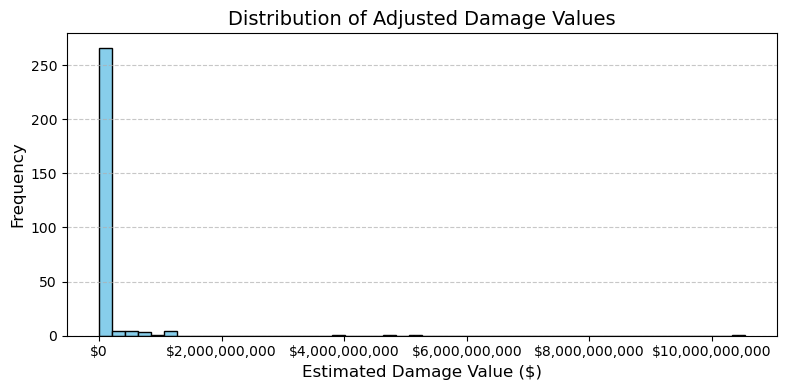

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(fire_damages['Estimated Damage'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Adjusted Damage Values', fontsize=14)
plt.xlabel('Estimated Damage Value ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format x-axis as currency
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


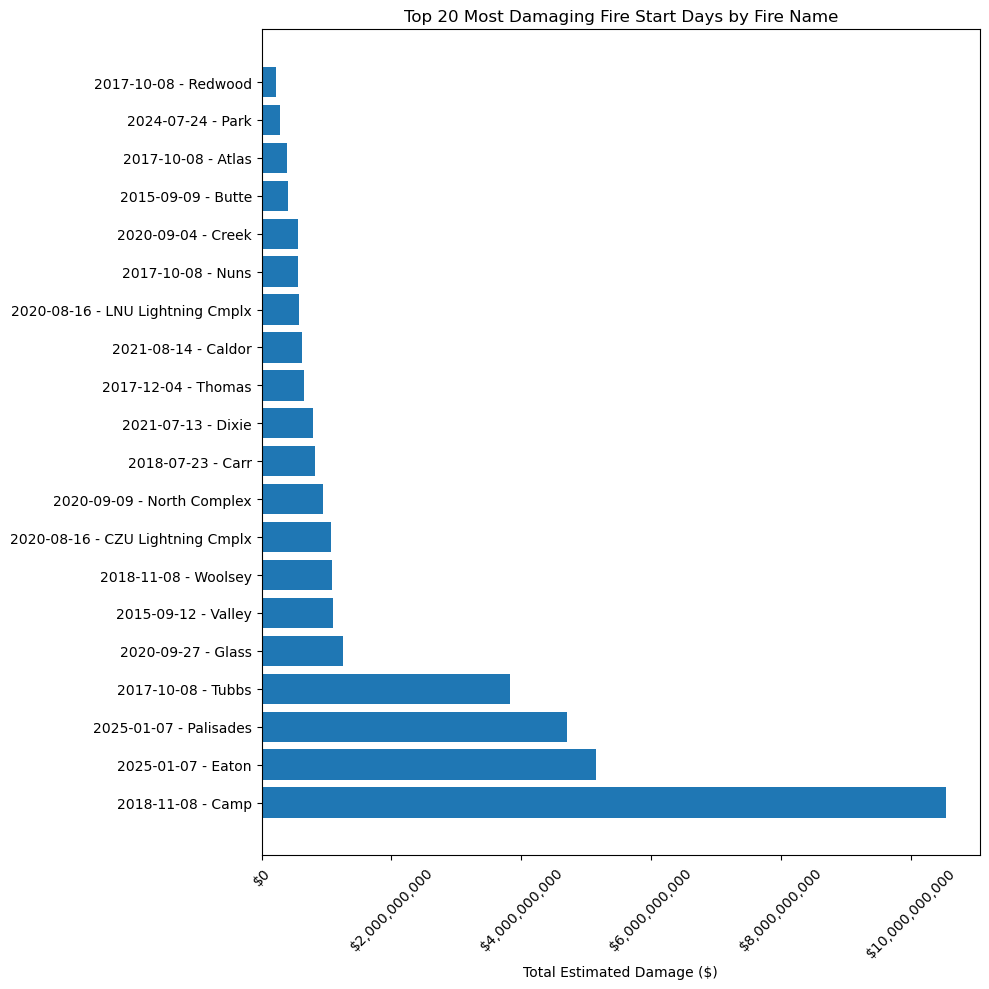

In [26]:
top_days = fire_damages.sort_values('Estimated Damage', ascending=False).head(20)
plt.figure(figsize=(10, 10))
plt.barh(top_days['Start'].astype(str) + ' - ' + top_days['Fire Name'], top_days['Estimated Damage'])
plt.title("Top 20 Most Damaging Fire Start Days by Fire Name")
plt.xlabel("Total Estimated Damage ($)")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()

### 3.2 Geographical Visualization

In [27]:
counties_gdf = gpd.read_file('../data/raw/CA_Counties.shp').to_crs(epsg=4326)

In [28]:
fire_gdf = gpd.GeoDataFrame(
    fire_damages,
    geometry=gpd.points_from_xy(fire_damages['Lon'], fire_damages['Lat']),
    crs='EPSG:4326'
)

In [29]:
fire_proj = fire_gdf.to_crs(epsg=3310)         # California Albers
counties_proj = counties_gdf.to_crs(epsg=3310)

In [30]:
# Dissolve counties into one state-wide shape
california_boundary = counties_proj.unary_union
fire_clipped = fire_proj[fire_proj.geometry.within(california_boundary)]

In [31]:
x = fire_clipped.geometry.x
y = fire_clipped.geometry.y

# Clean/scale weights to avoid extreme influence
weights = fire_clipped['Estimated Damage'].clip(upper=1e7)  # Optional: cap very large values

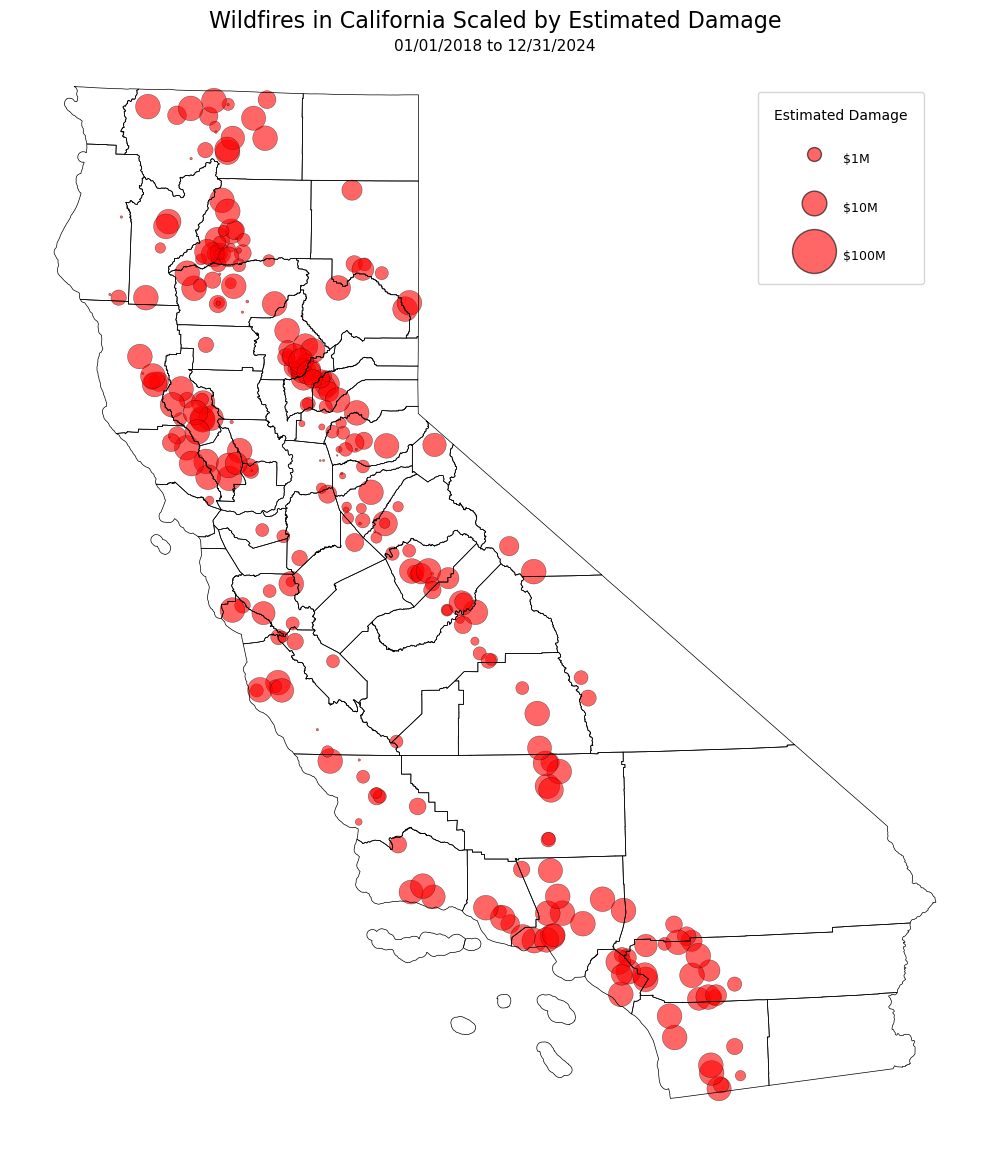

In [32]:
# Clean damage values (optional: clip large outliers for better scaling)
damage = fire_proj['Estimated Damage'].clip(upper=1e7)

# Scale circle sizes
circle_sizes = np.sqrt(damage) / 10 # Square root to reduce skew, adjust divisor to taste

# Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot counties
counties_proj.boundary.plot(ax=ax, color='black', linewidth=0.5)

# Plot fire points with scaled size
fire_proj.plot(
    ax=ax,
    markersize=circle_sizes,
    color='red',
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

# Custom legend
legend_values = [1e6, 1e7, 1e8]  # Reference damages
legend_sizes = [np.sqrt(v) / 10 for v in legend_values]

# Create dummy points for the legend
for size, label in zip(legend_sizes, ['$1M', '$10M', '$100M']):
    ax.scatter([], [], s=size, color='red', alpha=0.6, edgecolor='black', label=label)

# Apply vertical spacing and style
ax.legend(
    title='Estimated Damage',
    loc='upper right',
    frameon=True,
    labelspacing=2.0,      # vertical spacing between labels
    handleheight=2.5,
    handlelength=3.0,  # increases size of blank marker handles
    borderpad=1.3,         # space between legend border and content
    borderaxespad=4.5,     # space between legend and axes
    title_fontsize=10,
    fontsize=9
)


# Add title and formatting
ax.set_title("Wildfires in California Scaled by Estimated Damage", fontsize=16)
ax.text(
    0.5, .987,  # X and Y position in axis coordinates (centered)
    "01/01/2018 to 12/31/2024",
    transform=ax.transAxes,
    ha='center',
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.savefig("../plots/fire_damage_circles.png", dpi=300)
plt.show()



---

## 4. Export File

In [33]:
fire_damages.rename(columns={
    'Lat': 'Fire_Latitude',
    'Lon': 'Fire_Longitude',
    'Start':'Date'
}, inplace=True)

In [34]:
fire_damages.to_csv("../data/raw/damage/fire_damages.csv",index=False)